In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, 
                             confusion_matrix, classification_report,
                             RocCurveDisplay)
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("telco_churn_clean.csv")
print("Shape:", df.shape)
print("Churn balance:\n", df['Churn'].value_counts())

Shape: (7032, 27)
Churn balance:
 0    5163
1    1869
Name: Churn, dtype: int64


In [2]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print("Features:", X.shape[1])
print("Target distribution:\n", y.value_counts(normalize=True).round(3))

Features: 26
Target distribution:
 0    0.734
1    0.266
Name: Churn, dtype: float64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size: ", X_test.shape[0])
print("Churn rate in train:", round(y_train.mean(), 3))
print("Churn rate in test: ", round(y_test.mean(), 3))

Train size: 5625
Test size:  1407
Churn rate in train: 0.266
Churn rate in test:  0.266


In [5]:
# Logistic Regression is sensitive to scale — Random Forest is not
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled")

Features scaled


In [6]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

print("=== LOGISTIC REGRESSION ===")
print(f"Accuracy : {accuracy_score(y_test, lr_preds):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, lr_probs):.3f}")

=== LOGISTIC REGRESSION ===
Accuracy : 0.799
ROC-AUC  : 0.838


In [7]:
rf = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees
    max_depth=10,        # prevents overfitting
    random_state=42
)
rf.fit(X_train, y_train)   # no scaling needed for RF

rf_preds = rf.predict(X_test)
rf_probs = rf.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST ===")
print(f"Accuracy : {accuracy_score(y_test, rf_preds):.3f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, rf_probs):.3f}")

=== RANDOM FOREST ===
Accuracy : 0.793
ROC-AUC  : 0.834


In [8]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, rf_preds)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_probs),
        roc_auc_score(y_test, rf_probs)
    ]
}).round(3)

print(results.to_string(index=False))

              Model  Accuracy  ROC-AUC
Logistic Regression     0.799    0.838
      Random Forest     0.793    0.834


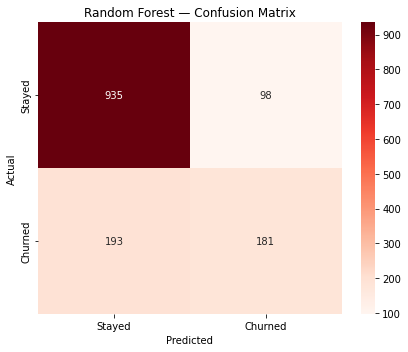


Correctly predicted stayed  : 935
Correctly predicted churned : 181
Missed churners (false neg) : 193  ← customers we failed to save
False alarms   (false pos)  : 98  ← wasted retention spend


In [9]:
cm = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Plain English breakdown
tn, fp, fn, tp = cm.ravel()
print(f"\nCorrectly predicted stayed  : {tn}")
print(f"Correctly predicted churned : {tp}")
print(f"Missed churners (false neg) : {fn}  ← customers we failed to save")
print(f"False alarms   (false pos)  : {fp}  ← wasted retention spend")

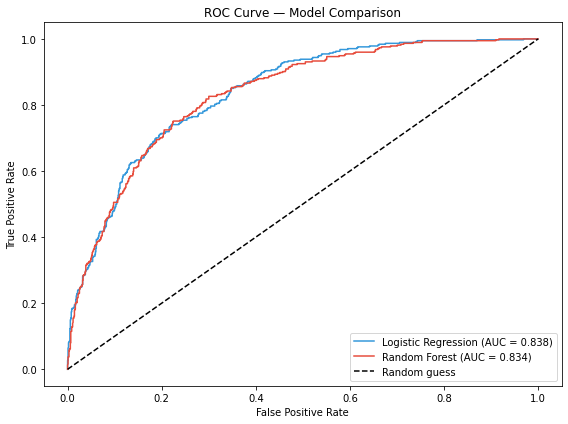

In [11]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))

# Logistic Regression curve
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
lr_auc = auc(lr_fpr, lr_tpr)
ax.plot(lr_fpr, lr_tpr, color="#3498db", 
        label=f"Logistic Regression (AUC = {lr_auc:.3f})")

# Random Forest curve
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
rf_auc = auc(rf_fpr, rf_tpr)
ax.plot(rf_fpr, rf_tpr, color="#e74c3c", 
        label=f"Random Forest (AUC = {rf_auc:.3f})")

# Random guess line
ax.plot([0, 1], [0, 1], 'k--', label='Random guess')

ax.set_title('ROC Curve — Model Comparison')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

<ipython-input-12-6ea5dca580d0>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature',


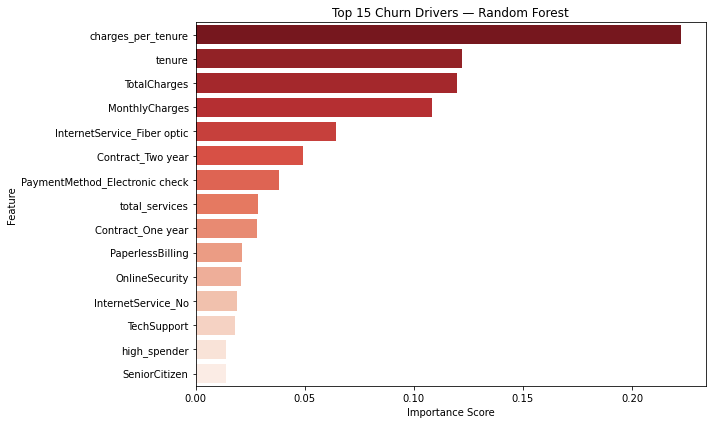

                       Feature  Importance
            charges_per_tenure    0.222618
                        tenure    0.121981
                  TotalCharges    0.119686
                MonthlyCharges    0.108363
   InternetService_Fiber optic    0.064242
             Contract_Two year    0.049232
PaymentMethod_Electronic check    0.038073
                total_services    0.028627
             Contract_One year    0.028282
              PaperlessBilling    0.021289
                OnlineSecurity    0.020600
            InternetService_No    0.018970
                   TechSupport    0.017890
                  high_spender    0.013810
                 SeniorCitizen    0.013747


In [12]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', 
            palette='Reds_r')
plt.title('Top 15 Churn Drivers — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print(importance_df.to_string(index=False))

In [13]:
import joblib

joblib.dump(rf, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model saved as churn_model.pkl")
print("Scaler saved as scaler.pkl")
print("\nFiles ready for the dashboard!")

Model saved as churn_model.pkl
Scaler saved as scaler.pkl

Files ready for the dashboard!
